# LOSO Validation
This will probably be the last notebook on pure classification over EEG data. Maybe I will add some exploring on the EEG-SPDNet later.<br>
This notebook is to assess the cross-subject generalization of learned features and geometric spaces of EEGNet and a SVM fitted to SPD data (for now).<br>
We will use the parameters used in other notebooks, i.e.:
- EEGNet: 4-2; dropout = 0.5; 75 epochs.
- SVM: 5 xDawn filters; linear kernel; riemann metric; lwf estimator; OvA classification.

The LOSO validation works in a simple fashion: we will train and fit the models to all data of 9 subjects, validating it on one subject only.<br>
This will give enough data for the deep model to learn - and we may test other parametrizations for the SVM - and enough data for we to see if they perform well on unseen subjects.

In [10]:
# Lib
import sys
sys.path.append("/home/rffl/files/eegconv/")

from riemannSVM import SVMxDawn_regular as SVMreg
from torch.utils.data import DataLoader
import eegnet # type: ignore
import datagen
import eegdataset

# Parameters
classvec = [i+1 for i in range(10)]
submat = [[i+1 for i in range(10) if i+1 != j+1] for j in range(10)]

## EEGNet

==================== Subject 1 Out ====================
Saved ./train.npy shape = (7200, 17, 100)
Saved ./test.npy shape = (800, 17, 100)
Epoch 1: Train loss 2.3017, acc 0.1144 | Test loss 2.2806, acc 0.1562
Epoch 2: Train loss 2.2653, acc 0.1417 | Test loss 2.2412, acc 0.1837
Epoch 3: Train loss 2.2403, acc 0.1647 | Test loss 2.2209, acc 0.1938
Epoch 4: Train loss 2.2227, acc 0.1771 | Test loss 2.1997, acc 0.1800
Epoch 5: Train loss 2.2100, acc 0.1837 | Test loss 2.1725, acc 0.2213
Epoch 6: Train loss 2.2020, acc 0.1849 | Test loss 2.1804, acc 0.2225
Epoch 7: Train loss 2.1958, acc 0.1864 | Test loss 2.1597, acc 0.2425
Epoch 8: Train loss 2.1841, acc 0.1925 | Test loss 2.1394, acc 0.2275
Epoch 9: Train loss 2.1830, acc 0.1910 | Test loss 2.1374, acc 0.2562
Epoch 10: Train loss 2.1714, acc 0.2031 | Test loss 2.1276, acc 0.2350
Epoch 11: Train loss 2.1711, acc 0.2044 | Test loss 2.1247, acc 0.2313
Epoch 12: Train loss 2.1589, acc 0.2050 | Test loss 2.1135, acc 0.2250
Epoch 13: Train los

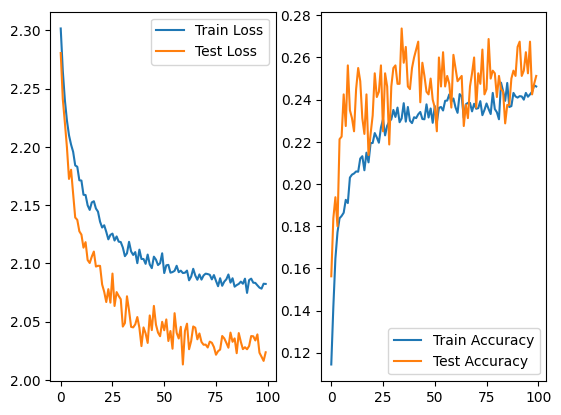

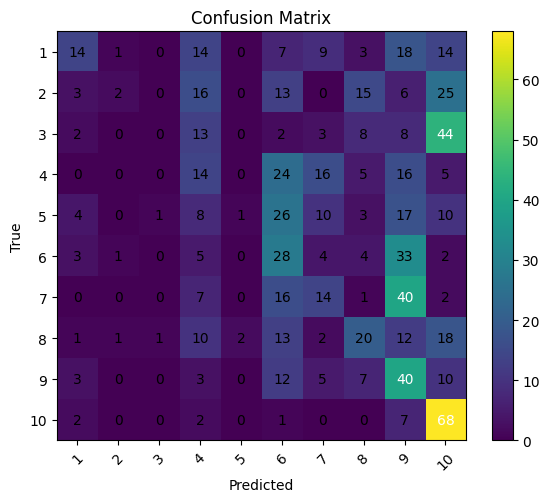

==================== Subject 2 Out ====================
Saved ./train.npy shape = (7200, 17, 100)
Saved ./test.npy shape = (800, 17, 100)
Epoch 1: Train loss 2.3011, acc 0.1117 | Test loss 2.2801, acc 0.1313
Epoch 2: Train loss 2.2616, acc 0.1489 | Test loss 2.2330, acc 0.1663
Epoch 3: Train loss 2.2445, acc 0.1529 | Test loss 2.2154, acc 0.1850
Epoch 4: Train loss 2.2335, acc 0.1581 | Test loss 2.1977, acc 0.2150
Epoch 5: Train loss 2.2243, acc 0.1643 | Test loss 2.1820, acc 0.2412
Epoch 6: Train loss 2.2062, acc 0.1929 | Test loss 2.1761, acc 0.2362
Epoch 7: Train loss 2.2018, acc 0.1783 | Test loss 2.1634, acc 0.2387
Epoch 8: Train loss 2.1898, acc 0.1868 | Test loss 2.1516, acc 0.2550
Epoch 9: Train loss 2.1718, acc 0.1953 | Test loss 2.1401, acc 0.2625
Epoch 10: Train loss 2.1684, acc 0.2007 | Test loss 2.1329, acc 0.2838
Epoch 11: Train loss 2.1673, acc 0.2001 | Test loss 2.1362, acc 0.2863
Epoch 12: Train loss 2.1637, acc 0.2056 | Test loss 2.1253, acc 0.2913
Epoch 13: Train los

KeyboardInterrupt: 

In [8]:
for i in range(10):
    print(f'==================== Subject {i+1} Out ====================')
    train_path = datagen.generatedataset(classvec, submat[i], 1, False, single=True)
    test_path = datagen.generatedataset(classvec, [i+1], 1, False, out_path_train="./test.npy", single=True)

    trainDataset = eegdataset.KClassDataset(len(classvec), train_path)
    trainLoader = DataLoader(trainDataset, 12, True, num_workers=3)

    testDataset = eegdataset.KClassDataset(len(classvec), test_path)
    testLoader = DataLoader(testDataset, 12, True, num_workers=3)

    eegnet.regular_train(17, 100, 100, len(classvec), trainLoader, testLoader, 100, False, classvec)

## SVM

==================== Subject 1 Out ====================
Saved ./train.npy shape = (7200, 17, 100)
Saved ./test.npy shape = (800, 17, 100)
Train Acc 0.8551388888888889
Test Acc 0.365


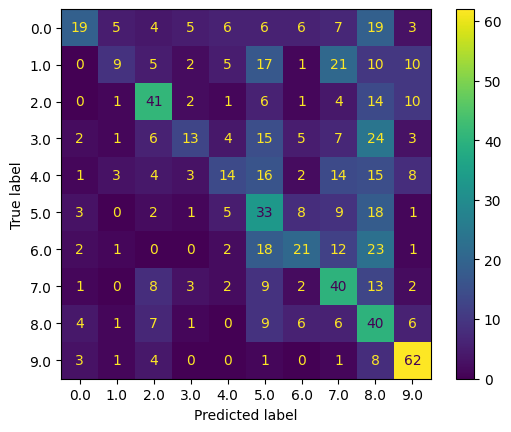

==================== Subject 2 Out ====================
Saved ./train.npy shape = (7200, 17, 100)
Saved ./test.npy shape = (800, 17, 100)
Train Acc 0.8615277777777778
Test Acc 0.33


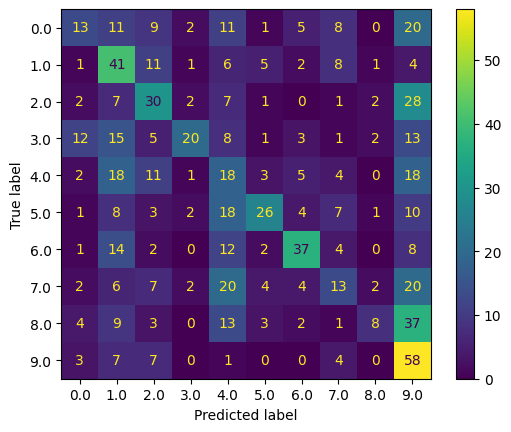

==================== Subject 3 Out ====================
Saved ./train.npy shape = (7200, 17, 100)
Saved ./test.npy shape = (800, 17, 100)
Train Acc 0.8490277777777778
Test Acc 0.36625


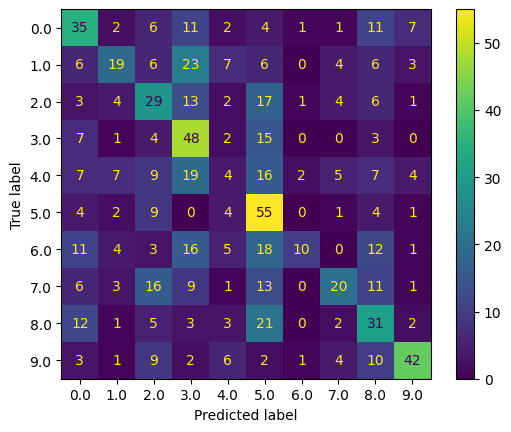

==================== Subject 4 Out ====================
Saved ./train.npy shape = (7200, 17, 100)
Saved ./test.npy shape = (800, 17, 100)


KeyboardInterrupt: 

In [11]:
for i in range(10):
    print(f'==================== Subject {i+1} Out ====================')
    train_path = datagen.generatedataset(classvec, submat[i], 1, False, single=True)
    test_path = datagen.generatedataset(classvec, [i+1], 1, False, out_path_train="./test.npy", single=True)

    SVMreg(train_path, test_path, classvec)